# 08 — Training-Data Pareto Validation

**Method**: Shen et al. (2024), *Computational Materials Science* — validate inverse design
by checking whether predicted Pareto solutions **extend beyond** the Pareto frontier
formed by the original training data.

If predicted solutions lie beyond (up-right of) the training Pareto → optimization succeeded.
If they fall behind or overlap → no improvement over known alloys in the training set.

## Three-layer validation (all self-contained, no external data)

| Layer | Question | Method |
|-------|----------|--------|
| 1 | Does predicted Pareto extend beyond training Pareto? | Overlay plot per cluster |
| 2 | How much improvement, quantitatively? | Hypervolume ratio + % points beyond training front |
| 3 | Is the model interpolating or extrapolating? | Composition distance to nearest training point |

**Why re-run clustering?** N06 only saved cluster labels for the 235 Pareto solutions,
not all 345 training samples. To compute \"training Pareto per cluster\" we need every
training sample assigned. The clustering is deterministic (K=5, random_state=42) so
results match N06 exactly.

**NaN handling**: `metal_cleaned.csv` element columns are filled with 0 (same as N06).
Rows where YS/UTS/El are NaN are excluded from Pareto computation.

**Input**: `data/metal_cleaned.csv`, `optimization_results/cluster_pareto.csv`  
**Output**: `figure/training_pareto_validation.pdf`

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist, pdist
warnings.filterwarnings('ignore')

OPT_DIR = os.path.join('..', 'optimization_results')
FIGURE_DIR = os.path.join('..', 'figure')
os.makedirs(FIGURE_DIR, exist_ok=True)
SAVE_DPI = 600

ELEMENTS = ['Si','Fe','Cu','Mn','Mg','Cr','Zn','V','Ti','Zr','Li','Ni','Be','Sc']
colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e']

In [2]:
# === Load N06-clustered training data (pre-computed, no re-clustering) ===
# Generated by N06 cell-9: df_all with fillna(0) + KMeans(random_state=42)
df_all = pd.read_csv(os.path.join(OPT_DIR, 'training_clustered.csv'))

# Verify cluster labels match N06
cluster_info = {}
for c in sorted(df_all['cluster'].unique()):
    mask = df_all['cluster'] == c
    cdf = df_all[mask]
    sig = [e for e in ELEMENTS if cdf[e].mean() > 0.005]
    label = '+'.join(sig[:3]) if sig else f'C{c+1}'
    cluster_info[c] = {'label': label, 'n': mask.sum(), 'id': c+1}
    n_valid = cdf[['YS','UTS','El']].notna().all(axis=1).sum()
    print(f'C{c+1}: {mask.sum():>3} samples, {n_valid} with YS/UTS/El, dominant: {label}')

# Flag valid targets for Pareto computation
df_all['valid_target'] = df_all[['YS','UTS','El']].notna().all(axis=1)
print(f'Total: {len(df_all)} rows, {df_all["valid_target"].sum()} with complete targets')
print()

# === Load N06 Pareto solutions ===
df_pareto = pd.read_csv(os.path.join(OPT_DIR, 'cluster_pareto.csv'))
if 'cluster_id' in df_pareto.columns:
    df_pareto['cid'] = df_pareto['cluster_id']
else:
    df_pareto['cid'] = df_pareto['cluster'] + 1
print(f'Loaded {len(df_pareto)} predicted Pareto solutions from {df_pareto["cid"].nunique()} clusters')

C1:  53 samples, 53 with YS/UTS/El, dominant: Cu+Mg+Zn
C2: 168 samples, 130 with YS/UTS/El, dominant: Si+Cu+Mg
C3:  99 samples, 70 with YS/UTS/El, dominant: Cu+Mg+Zn
C4:  40 samples, 40 with YS/UTS/El, dominant: Si+Cu+Mg
C5: 134 samples, 129 with YS/UTS/El, dominant: Cu+Mg+Zn
Total: 494 rows, 422 with complete targets

Loaded 235 predicted Pareto solutions from 5 clusters


In [3]:
# === Pareto non-dominated sorting ===
def pareto_mask(ys, uts, el):
    """3-objective non-dominated mask (maximize all three)."""
    valid = ~(np.isnan(ys) | np.isnan(uts) | np.isnan(el))
    if not valid.all():
        ys, uts, el = ys[valid], uts[valid], el[valid]
    costs = np.column_stack([-ys, -uts, -el])
    n = costs.shape[0]
    eff = np.ones(n, dtype=bool)
    for i in range(n):
        if not eff[i]:
            continue
        dominated = (np.all(costs[eff] <= costs[i], axis=1) &
                    np.any(costs[eff] < costs[i], axis=1))
        eff[eff] = ~dominated
        eff[i] = True
    return eff

def pareto_2d(ys, el):
    """2-objective non-dominated mask (maximize YS, maximize El)."""
    valid = ~(np.isnan(ys) | np.isnan(el))
    if not valid.all():
        ys, el = ys[valid], el[valid]
    costs = np.column_stack([-ys, -el])
    n = costs.shape[0]
    eff = np.ones(n, dtype=bool)
    for i in range(n):
        if not eff[i]:
            continue
        dominated = (np.all(costs[eff] <= costs[i], axis=1) &
                    np.any(costs[eff] < costs[i], axis=1))
        eff[eff] = ~dominated
        eff[i] = True
    return eff

# === Hypervolume (2D: YS vs El) ===
def hypervolume_2d(ys, el, ref_ys, ref_el):
    """Compute 2D hypervolume for maximize-YS, maximize-El Pareto front."""
    valid = ~(np.isnan(ys) | np.isnan(el))
    ys, el = ys[valid], el[valid]
    if len(ys) == 0:
        return 0.0
    idx = np.argsort(ys)
    ys_s, el_s = ys[idx], el[idx]
    # Remove non-Pareto points (el must be descending when ys is ascending)
    keep = np.ones(len(ys_s), dtype=bool)
    best_el = -np.inf
    for i in range(len(ys_s) - 1, -1, -1):
        if el_s[i] <= best_el:
            keep[i] = False
        else:
            best_el = el_s[i]
    ys_s, el_s = ys_s[keep], el_s[keep]
    hv = 0.0
    prev_ys = ref_ys
    for i in range(len(ys_s)):
        if ys_s[i] > prev_ys and el_s[i] > ref_el:
            hv += (ys_s[i] - prev_ys) * (el_s[i] - ref_el)
            prev_ys = ys_s[i]
    return max(hv, 0.0)

# === Composition distance to nearest training point ===
def nearest_train_dist(pareto_comp, train_comp):
    """Euclidean distance from each Pareto point to nearest training point."""
    dists = cdist(pareto_comp, train_comp, metric='euclidean')
    return dists.min(axis=1)

## Layer 1 & 2: Pareto Overlay + Hypervolume Quantification

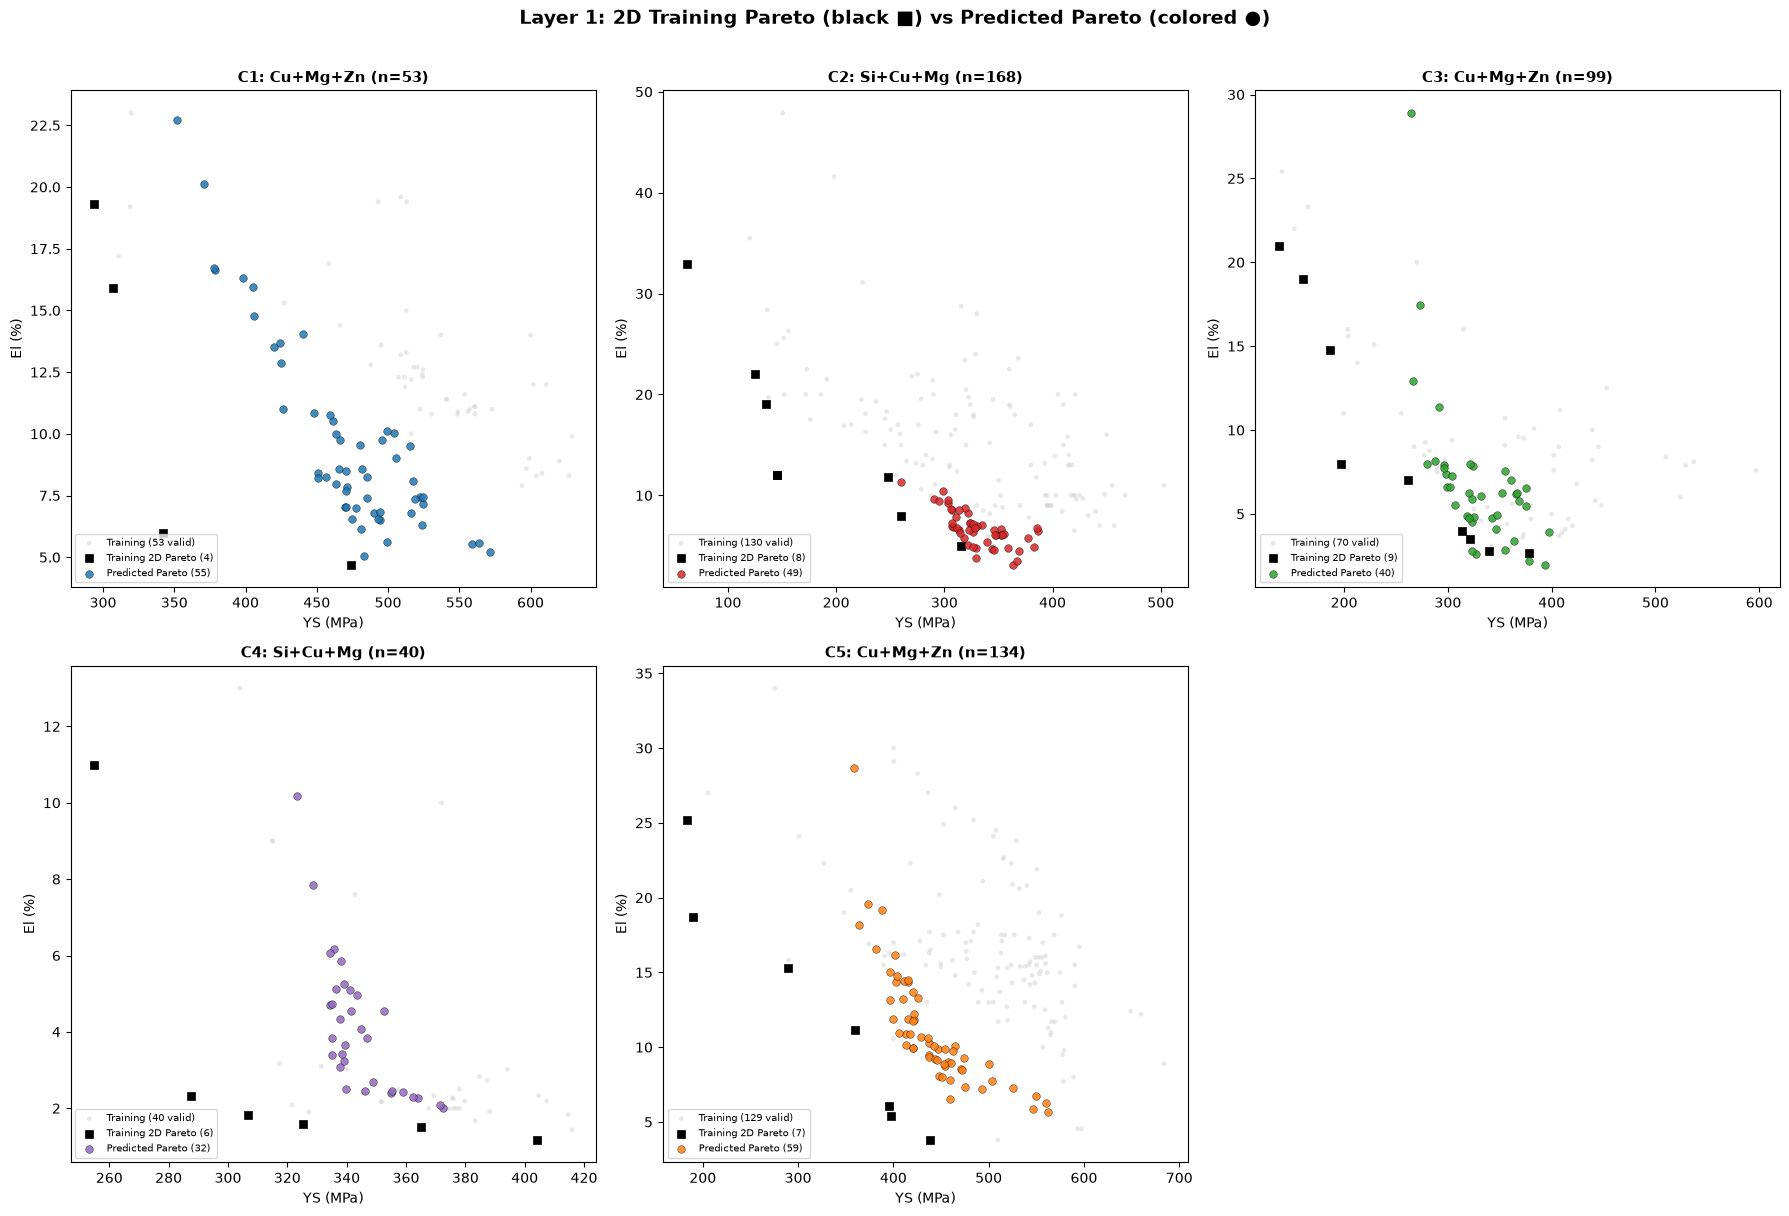

In [4]:
results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Global nadir for hypervolume reference
ref_ys = df_all.loc[df_all['valid_target'], 'YS'].min() - 10
ref_el = df_all.loc[df_all['valid_target'], 'El'].min() - 1

for ci, c in enumerate(sorted(cluster_info.keys())):
    ax = axes[ci]
    info = cluster_info[c]
    cid = info['id']

    # ---- Training data: this cluster, valid targets only ----
    train_mask = (df_all['cluster'] == c) & df_all['valid_target']
    train_ys = df_all.loc[train_mask, 'YS'].values.astype(float)
    train_uts = df_all.loc[train_mask, 'UTS'].values.astype(float)
    train_el = df_all.loc[train_mask, 'El'].values.astype(float)
    train_comp = df_all.loc[train_mask, ELEMENTS].fillna(0).values.astype(float)

    # Training 2D Pareto (YS, El) — for the plot, matches what the eye sees
    train_p2 = pareto_2d(train_ys, train_el)
    # Training 3D Pareto (YS, UTS, El) — for hypervolume & metrics
    train_p3 = pareto_mask(train_ys, train_uts, train_el)

    # ---- Predicted Pareto ----
    pred_mask = df_pareto['cid'] == cid
    pred_ys = df_pareto.loc[pred_mask, 'YS_pred'].values
    pred_el = df_pareto.loc[pred_mask, 'El_pred'].values
    pred_comp = df_pareto.loc[pred_mask, ELEMENTS].fillna(0).values

    # ---- Layer 1: Plot (uses 2D Pareto so black squares = visible upper-right boundary) ----
    ax.scatter(train_ys, train_el, c='lightgray', s=12, alpha=0.5, edgecolors='none',
              label=f'Training ({len(train_ys)} valid)')
    ax.scatter(train_ys[train_p2], train_el[train_p2], c='black', s=35, marker='s',
              edgecolors='k', linewidth=0.5, zorder=5,
              label=f'Training 2D Pareto ({train_p2.sum()})')
    ax.scatter(pred_ys, pred_el, c=colors[ci], s=30, alpha=0.85,
              edgecolors='k', linewidth=0.3, zorder=10,
              label=f'Predicted Pareto ({len(pred_ys)})')

    ax.set_xlabel('YS (MPa)')
    ax.set_ylabel('El (%)')
    ax.set_title(f'C{cid}: {info["label"]} (n={info["n"]})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7, loc='lower left')

    # ---- Layer 2: Hypervolume (uses 2D Pareto for both train & pred) ----
    hv_train = hypervolume_2d(train_ys[train_p2], train_el[train_p2], ref_ys, ref_el)
    hv_pred = hypervolume_2d(pred_ys, pred_el, ref_ys, ref_el)
    hv_ratio = hv_pred / hv_train if hv_train > 0 else float('nan')

    # % predicted points dominating at least 1 training 2D Pareto point
    tp_ys = train_ys[train_p2]; tp_el = train_el[train_p2]
    n_beyond = 0
    for i in range(len(pred_ys)):
        if ((pred_ys[i] > tp_ys) & (pred_el[i] > tp_el)).any():
            n_beyond += 1
    pct_beyond = 100 * n_beyond / len(pred_ys) if len(pred_ys) > 0 else 0

    # Track 3D Pareto info for reference
    train_ys_max_3d = np.nanmax(train_ys[train_p3]) if train_p3.sum() > 0 else np.nan
    train_el_max_3d = np.nanmax(train_el[train_p3]) if train_p3.sum() > 0 else np.nan
    pred_ys_max = np.nanmax(pred_ys)
    pred_el_max = np.nanmax(pred_el)

    # ---- Layer 3: Composition extrapolation check ----
    nn_dists = nearest_train_dist(pred_comp, train_comp)
    if len(train_comp) >= 3:
        train_pair_dists = pdist(train_comp, metric='euclidean')
        extrap_threshold = np.percentile(train_pair_dists, 95)
        n_extrap = int((nn_dists > extrap_threshold).sum())
        pct_extrap = 100.0 * n_extrap / len(nn_dists)
    else:
        pct_extrap = 0.0

    results[cid] = {
        'label': info['label'],
        'n_train': info['n'],
        'n_valid': len(train_ys),
        'n_train_pareto_2d': int(train_p2.sum()),
        'n_train_pareto_3d': int(train_p3.sum()),
        'n_pred_pareto': len(pred_ys),
        'hv_train': hv_train,
        'hv_pred': hv_pred,
        'hv_ratio': hv_ratio,
        'pct_beyond': pct_beyond,
        'train_ys_max_3d': train_ys_max_3d,
        'pred_ys_max': pred_ys_max,
        'train_el_max_3d': train_el_max_3d,
        'pred_el_max': pred_el_max,
        'nn_dist_mean': float(nn_dists.mean()),
        'nn_dist_max': float(nn_dists.max()),
        'pct_extrap': pct_extrap,
    }

axes[5].set_visible(False)
fig.suptitle('Layer 1: 2D Training Pareto (black ■) vs Predicted Pareto (colored ●)',
            fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'training_pareto_validation.pdf'), dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## Layer 3 Detail: Composition Interpolation vs Extrapolation

For each predicted Pareto point: Euclidean distance to nearest training sample
in the same cluster. Threshold = 95th percentile of all pairwise training distances.
Points beyond threshold = extrapolation risk.

In [5]:
print(f'{"Cluster":<10} {"Mean NN dist":>12} {"Max NN dist":>12} {"95% Threshold":>14} {"Extrap%":>8}')
print('-' * 60)
for cid in sorted(results.keys()):
    r = results[cid]
    label = f'C{cid}'
    train_mask = (df_all['cluster'] == (cid - 1)) & df_all['valid_target']
    train_comp = df_all.loc[train_mask, ELEMENTS].fillna(0).values
    if len(train_comp) >= 3:
        thr = np.percentile(pdist(train_comp, metric='euclidean'), 95)
    else:
        thr = float('nan')
    print(f'{label:<10} {r["nn_dist_mean"]:>12.4f} {r["nn_dist_max"]:>12.4f} {thr:>14.4f} {r["pct_extrap"]:>7.1f}%')

print()
print('Interpretation:')
print('  Mean dist << threshold  = Pareto solutions are well within training data coverage')
print('  Mean dist ~= threshold  = near edge of training data')
print('  Extrap% high             = many solutions in sparsely sampled regions → lower confidence')

Cluster    Mean NN dist  Max NN dist  95% Threshold  Extrap%
------------------------------------------------------------
C1               0.0056       0.0093         0.0622     0.0%
C2               0.0139       0.0261         0.0669     0.0%
C3               0.0176       0.0317         0.0665     0.0%
C4               0.0210       0.0306         0.1183     0.0%
C5               0.0053       0.0104         0.0313     0.0%

Interpretation:
  Mean dist << threshold  = Pareto solutions are well within training data coverage
  Mean dist ~= threshold  = near edge of training data
  Extrap% high             = many solutions in sparsely sampled regions → lower confidence


## Validation Summary

Three criteria → one rating per cluster:
- **Improvement**: Did the optimization find solutions beyond the training Pareto?
- **Reliability**: Is the model interpolating (safe) or extrapolating (risky)?
- **Coverage**: Does the cluster have enough training data to trust the model?

In [6]:
print(f'{"Cluster":<22} {"All":>5} {"Valid":>6} {"Tr.P2D":>7} {"Tr.P3D":>7} {"Pred.P":>7}  |  '
      f'{"HV Ratio":>8} {"Beyond%":>7} {"ΔYS_max":>8} {"ΔEl_max":>9}  |  '
      f'{"Extrap%":>7}  |  {"Rating":>22}')
print('-' * 125)

for cid in sorted(results.keys()):
    r = results[cid]
    label = f'C{cid} {r["label"]}'

    dy = r['pred_ys_max'] - r['train_ys_max_3d'] if not np.isnan(r['train_ys_max_3d']) else float('nan')
    de = r['pred_el_max'] - r['train_el_max_3d'] if not np.isnan(r['train_el_max_3d']) else float('nan')

    score = 0
    if r['hv_ratio'] > 1.20:  score += 3
    elif r['hv_ratio'] > 1.05: score += 2
    elif r['hv_ratio'] > 1.00: score += 1
    if r['pct_extrap'] < 5:   score += 3
    elif r['pct_extrap'] < 20: score += 2
    elif r['pct_extrap'] < 50: score += 1
    if r['n_valid'] >= 100:   score += 3
    elif r['n_valid'] >= 60:  score += 2
    elif r['n_valid'] >= 30:  score += 1

    if score >= 7:   rating = 'A — High confidence'
    elif score >= 5: rating = 'B — Moderate confidence'
    elif score >= 3: rating = 'C — Limited confidence'
    else:           rating = 'D — Unreliable'

    dy_str = f'{dy:>+8.0f}' if not np.isnan(dy) else '     nan'
    de_str = f'{de:>+9.1f}%' if not np.isnan(de) else '     nan%'

    print(f'{label:<22} {r["n_train"]:>5} {r["n_valid"]:>6} {r["n_train_pareto_2d"]:>7} {r["n_train_pareto_3d"]:>7} {r["n_pred_pareto"]:>7}  |  '
          f'{r["hv_ratio"]:>8.3f} {r["pct_beyond"]:>6.1f}% {dy_str:>8} {de_str:>9}  |  '
          f'{r["pct_extrap"]:>6.1f}%  |  {rating:>22}')

print()
print('Tr.P2D = Training 2D Pareto points (YS+El, drawn as black ■ on figure)')
print('Tr.P3D = Training 3D Pareto points (YS+UTS+El, hidden UTS dimension)')
print('ΔYS_max = predicted max YS − training 3D Pareto max YS')
print('ΔEl_max = predicted max El − training 3D Pareto max El')
print()
print('Hypervolume and Beyond% always use 2D Pareto (YS+El) — matches the eye.')

Cluster                  All  Valid  Tr.P2D  Tr.P3D  Pred.P  |  HV Ratio Beyond%  ΔYS_max   ΔEl_max  |  Extrap%  |                  Rating
-----------------------------------------------------------------------------------------------------------------------------
C1 Cu+Mg+Zn               53     53       4       6      55  |     1.643  100.0%      +98      -0.3%  |     0.0%  |     A — High confidence
C2 Si+Cu+Mg              168    130       8      15      49  |     0.939   63.3%      +44     -21.6%  |     0.0%  |  B — Moderate confidence
C3 Cu+Mg+Zn               99     70       9      10      40  |     2.052   82.5%      +20      +7.9%  |     0.0%  |     A — High confidence
C4 Si+Cu+Mg               40     40       6      11      32  |     1.208  100.0%      -32      -0.8%  |     0.0%  |     A — High confidence
C5 Cu+Mg+Zn              134    129       7       9      59  |     1.813  100.0%     +124      +3.5%  |     0.0%  |     A — High confidence

Tr.P2D = Training 2D Pareto point

In [7]:
print('\n=== PIPELINE COMPLETE ===')
print('N06: K-means K=5 \u2192 LHS 5000 \u2192 Champion \u2192 Pareto (5 constraints)')
print('N07: Cross-cluster Pareto overlay + best-per-cluster ranking')
print('N08: Training-data Pareto validation (Shen et al. 2024 method)')
print()
print('Validation layers:')
print('  \u2713 Layer 1: Overlay plot — predicted vs training Pareto per cluster')
print('  \u2713 Layer 2: Hypervolume ratio + % points dominating training Pareto')
print('  \u2713 Layer 3: Composition distance — interpolation vs extrapolation')
print()
print('All validation uses only local files: metal_cleaned.csv + cluster_pareto.csv')
print('No external data, no commercial alloys, no paywalled papers required.')


=== PIPELINE COMPLETE ===
N06: K-means K=5 → LHS 5000 → Champion → Pareto (5 constraints)
N07: Cross-cluster Pareto overlay + best-per-cluster ranking
N08: Training-data Pareto validation (Shen et al. 2024 method)

Validation layers:
  ✓ Layer 1: Overlay plot — predicted vs training Pareto per cluster
  ✓ Layer 2: Hypervolume ratio + % points dominating training Pareto
  ✓ Layer 3: Composition distance — interpolation vs extrapolation

All validation uses only local files: metal_cleaned.csv + cluster_pareto.csv
No external data, no commercial alloys, no paywalled papers required.
